In [201]:
import warnings
warnings.filterwarnings('ignore')

In [202]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [203]:
pd.set_option('display.max_columns', 100)

In [204]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [205]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,197,Republicans
1,286,Democrats
2,213,Republicans
3,195,Republicans
4,283,Democrats
...,...,...
19995,208,Republicans
19996,275,Democrats
19997,233,Democrats
19998,253,Democrats


In [206]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,147,1,0.005,Republicans
1,162,1,0.005,Republicans
2,168,1,0.005,Republicans
3,169,1,0.005,Republicans
4,171,1,0.005,Republicans


In [207]:
np.unique(seat_sims['seats']).shape[0]

185

In [208]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [209]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-08-30,229.365800,US House,seats
1,2026-08-30,66.120000,US House,chance
2,2026-08-30,22.784344,US House,seats_sd
3,2026-08-30,44.972806,AK-AL,y_pred
4,2026-08-30,3.555839,AK-AL,y_pred_sd


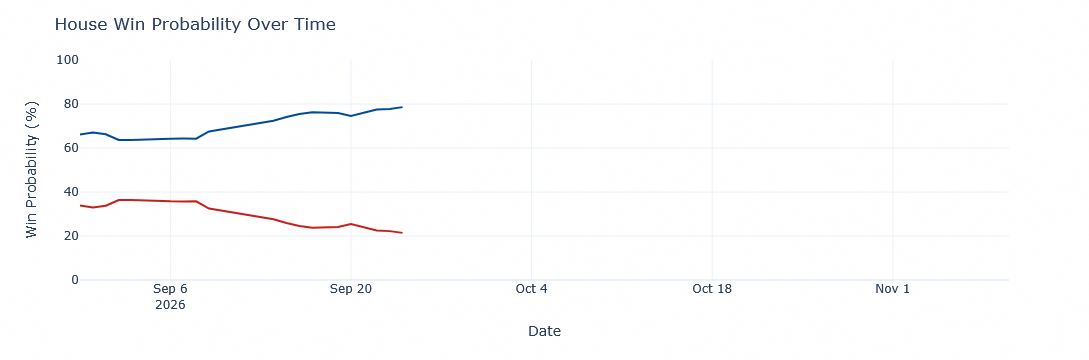

In [210]:
chance_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

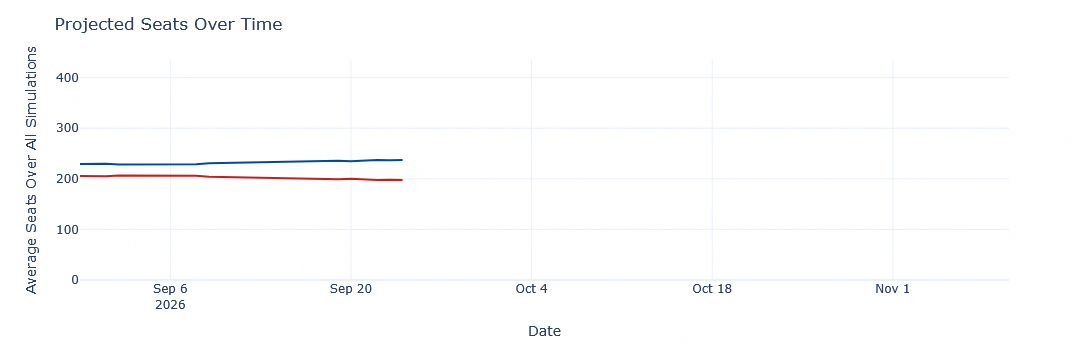

In [211]:
seats_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 435 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 435]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [212]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [213]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [214]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,19950,19951,19952,19953,19954,19955,19956,19957,19958,19959,19960,19961,19962,19963,19964,19965,19966,19967,19968,19969,19970,19971,19972,19973,19974,19975,19976,19977,19978,19979,19980,19981,19982,19983,19984,19985,19986,19987,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-9.353047,0.126899,-6.827314,-13.269077,0.370632,-7.720765,1.544114,-8.912572,-1.343088,-1.456844,-7.292181,-4.053557,-5.253250,-7.577734,-2.527819,-2.788555,-5.326618,-1.287585,-1.965213,1.388402,-7.128460,-2.934705,-2.415419,0.879627,1.323108,-7.957023,-1.977630,-5.321546,-3.218399,-4.101094,-3.901945,-10.279843,-1.978725,-2.756877,-0.653846,-9.085702,-10.752574,-3.666469,-2.027965,-1.967107,-2.594576,-4.651036,-3.308331,-6.906241,-6.496803,1.308638,-3.897254,-2.766859,-5.803955,-8.897619,...,-6.879648,-3.138885,-2.471628,-6.569296,-4.569996,-5.718567,-2.525941,-6.721177,3.831194,-3.465117,-8.609051,-9.472157,-2.891788,-6.730579,-2.226735,-6.877852,1.159493,-7.289342,1.440842,-6.859206,-2.207947,-7.934141,-2.837885,-8.594262,-5.048702,-1.848201,-5.334968,-2.500551,-4.433072,-1.025172,-8.657800,0.308868,-10.492218,6.349379,-10.367878,-7.980239,-2.290231,-4.781101,-8.155787,-1.158049,-5.804322,-7.605676,-1.907158,-3.582078,-0.552755,-8.745917,-1.856238,-3.666015,-8.540641,-6.797036
AL-01,-20.444588,-5.264663,-19.096686,-20.014969,-8.407915,-17.061261,-6.810953,-20.138605,-7.675941,-11.033585,-17.028773,-14.864572,-12.113358,-8.510373,-12.745668,-13.602227,-11.949030,-11.989709,-14.851541,-13.195164,-17.672717,-9.716738,-12.525581,-9.179491,-6.361746,-18.160406,-8.343926,-18.274912,-15.833383,-12.117520,-18.215561,-20.614994,-13.686455,-14.361077,-12.377164,-13.641932,-18.495508,-12.858398,-14.881839,-4.452412,-13.108526,-13.082589,-11.315416,-15.668247,-18.954978,-8.361693,-19.135097,-10.296477,-13.349937,-15.727504,...,-15.463967,-11.702480,-10.950743,-12.383957,-13.271197,-14.093034,-7.844376,-18.886601,-6.943080,-15.510631,-14.804087,-16.259236,-8.524003,-16.930285,-9.656762,-20.628194,-5.897264,-16.321705,-10.444368,-16.620705,-9.073474,-13.571253,-10.109415,-13.906116,-14.589611,-12.617927,-13.715434,-7.593549,-13.800634,-10.045285,-17.346650,-9.452583,-22.678911,-4.262461,-17.121143,-18.871716,-13.610612,-14.596321,-17.718215,-12.511082,-13.377865,-19.878486,-11.987865,-13.490130,-12.443836,-17.360451,-8.535873,-14.760077,-7.878171,-17.257376
AL-02,-9.287861,6.474008,-6.658780,-4.884318,4.089608,-3.873860,-1.728497,-2.720774,2.940297,0.253230,-0.221024,-0.491459,-3.270230,-1.681219,-2.981266,-1.330355,0.566870,-2.604882,1.830867,-0.848261,-5.692210,-2.140383,-1.264781,0.809438,3.185771,-6.931201,3.096360,-2.257823,-2.405327,4.141022,0.067759,-4.528532,-4.563897,2.417770,-3.484630,0.195598,-7.084237,-1.734889,-3.801169,2.298302,-1.192283,-1.354817,3.814359,-3.598935,-1.806420,6.925041,-7.119207,0.068734,-1.793010,-0.663639,...,2.991016,0.465852,0.201231,0.471258,-0.716655,-1.419173,-1.095138,-4.280118,0.380759,-0.868209,-3.140625,-4.953798,0.714732,-8.227854,2.266309,-7.337939,3.465065,-3.238130,1.977965,-0.209535,-2.011035,3.377489,3.437496,-2.133566,-4.260933,0.243882,-3.017449,1.939132,2.336524,2.503610,-8.345530,-3.038593,-7.225214,4.731660,-1.507372,4.216046,-0.935002,-4.084569,-2.940971,2.241861,-2.931427,-6.717149,-2.686347,0.020304,3.810560,-3.973122,4.085880,-2.754490,2.821188,-4.375056
AL-03,-24.234922,-16.682477,-25.320095,-26.935998,-17.186295,-23.226757,-14.855709,-18.311838,-17.128276,-18.684797,-17.730064,-21.062378,-19.944949,-14.797897,-19.703708,-18.188151,-21.400113,-21.690633,-21.528504,-15.786497,-25.100516,-18.288985,-18.403624,-12.570314,-12.616928,-26.620749,-14.749237,-24.480377,-23.805466,-19.332328,-21.794377,-24.255208,-15.861829,-21.365213,-15.554651,-17.411794,-25.023980,-17.312859,-22.218821,-18.013824,-22.271744,-20.623850,-17.922201,-22.331013,-22

In [215]:
sim_corr = post_untransp.corr()

In [216]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,...,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.713962,0.479345,0.734651,0.725255,0.715585,0.733311,0.492444,0.735136,0.737731,0.734220,0.737907,0.479978,0.483941,0.483800,0.497775,0.697838,0.718912,0.719803,0.720100,0.736589,0.697913,0.500831,0.506845,0.740223,0.730510,0.566024,0.505695,0.510127,0.503778,0.480491,0.694386,0.558345,0.501806,0.495577,0.700576,0.505188,0.738251,0.732103,0.505554,0.514676,0.703979,0.481606,0.507626,0.479341,0.517640,0.548501,0.506118,0.564335,0.507502,...,0.735293,0.718258,0.542032,0.505302,0.502068,0.702162,0.741167,0.699354,0.529825,0.502098,0.701496,0.520303,0.490724,0.493935,0.487958,0.729859,0.719219,0.719983,0.739004,0.547945,0.501836,0.474002,0.717514,0.731370,0.484038,0.505783,0.734216,0.484171,0.697683,0.527408,0.504341,0.507656,0.481657,0.700895,0.534746,0.480078,0.498976,0.505749,0.565402,0.490674,0.738427,0.536349,0.568957,0.732595,0.738371,0.697347,0.722640,0.731129,0.714252,0.696521
AL-01,0.713962,1.000000,0.486068,0.740713,0.732819,0.725229,0.739606,0.499496,0.738846,0.742751,0.740926,0.743217,0.486366,0.487678,0.495528,0.503108,0.701550,0.722849,0.723406,0.721195,0.738865,0.699691,0.505629,0.510206,0.746181,0.728838,0.569658,0.517914,0.512384,0.507774,0.493184,0.697355,0.566115,0.506389,0.506999,0.705393,0.512135,0.739124,0.732569,0.508889,0.516159,0.700378,0.485434,0.510213,0.483664,0.531804,0.560680,0.513523,0.575476,0.510402,...,0.736920,0.721345,0.556219,0.512880,0.502796,0.698922,0.746343,0.703747,0.541287,0.509481,0.704174,0.525858,0.496048,0.504993,0.493031,0.735321,0.724686,0.723920,0.742133,0.553171,0.513419,0.487650,0.711851,0.732465,0.483346,0.509368,0.741184,0.487154,0.705502,0.533969,0.505239,0.511618,0.485620,0.706827,0.541306,0.487901,0.504277,0.509922,0.573833,0.496587,0.739984,0.545147,0.575408,0.737150,0.746320,0.703822,0.722776,0.742698,0.720671,0.705137
AL-02,0.479345,0.486068,1.000000,0.489623,0.485412,0.477351,0.490983,0.699816,0.487485,0.495741,0.487732,0.496185,0.670589,0.665875,0.674335,0.690780,0.638101,0.475336,0.482054,0.475464,0.492424,0.630493,0.699293,0.706237,0.498234,0.488433,0.579322,0.697786,0.699022,0.520362,0.665834,0.633230,0.569052,0.695081,0.701701,0.635722,0.699667,0.493138,0.484424,0.705529,0.708469,0.634767,0.674920,0.700972,0.668861,0.536017,0.556162,0.703968,0.577307,0.706591,...,0.493818,0.480255,0.552448,0.699943,0.697243,0.631363,0.493635,0.635208,0.543966,0.696701,0.634973,0.534625,0.682504,0.680567,0.674182,0.485153,0.471240,0.478419,0.492953,0.551969,0.690958,0.665980,0.472233,0.486305,0.667105,0.708418,0.490592,0.668753,0.632332,0.540727,0.701094,0.698588,0.678508,0.639520,0.543613,0.662916,0.694622,0.694813,0.578060,0.683341,0.487881,0.544612,0.576492,0.488238,0.493434,0.635918,0.478921,0.493274,0.479521,0.639883
AL-03,0.734651,0.740713,0.489623,1.000000,0.754911,0.739737,0.765069,0.509815,0.753536,0.761319,0.759020,0.759597,0.497661,0.498101,0.500184,0.513976,0.717020,0.737320,0.736022,0.740271,0.760603,0.720286,0.515255,0.517647,0.761980,0.750963,0.577490,0.518048,0.525899,0.523221,0.498712,0.714543,0.571297,0.512161,0.512813,0.724875,0.520745,0.757827,0.751707,0.516548,0.526724,0.719218,0.498146,0.518980,0.495029,0.540722,0.570807,0.519254,0.581997,0.524391,...,0.757149,0.740228,0.558594,0.518165,0.514853,0.715488,0.766412,0.720092,0.543652,0.516085,0.721246,0.535862,0.502826,0.512643,0.502659,0.752582,0.740162,0.738597,0.760207,0.561044,0.514155,0.493038,0.73615

In [217]:
post.shape

(418, 20000)

In [218]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [219]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:40<00:00, 493.59it/s]


array(['MO-02', 'SC-01', 'OH-07', ..., 'MI-10', 'MI-10', 'NC-14'],
      shape=(20000,), dtype='<U32')

In [220]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,5,18.397008,0.000000,0.000000,0.000000,-37.097445,-45.710827,-1,-91.421653,30.287687,3.459777,0.000,4,23.558968,37.158289
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,3,8.220432,0.000000,0.000000,0.000000,-57.389541,-47.132870,-1,-94.265741,20.462282,3.504466,0.000,5,13.635894,27.364989


In [221]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157,1.190
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,5,18.397008,0.000000,0.000000,0.000000,-37.097445,-45.710827,-1,-91.421653,30.287687,3.459777,0.000,4,23.558968,37.158289,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,3,8.220432,0.000000,0.000000,0.000000,-57.389541,-47.132870,-1,-94.265741,20.462282,3.504466,0.000,5,13.635894,27.364989,0.000


In [222]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
229,229,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.000000,0.000000,37,3711,3,10000.000000,0.000000,0.000000,0.000000e+00,-1.462623,50.000000,0,100.000000,51.341620,3.613702,64.575,230,44.269970,58.501163,3.150
193,193,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-8.544738,0,0,45.000000,0.212756,45.000000,0.212756,East North Central,2026,0.0,0.000000,0.000000,26,2610,2,2190.629568,0.212756,0.461255,-1.460326e-07,3.273250,-3.195838,0,-6.391676,51.072060,3.595546,61.865,194,43.979238,58.162685,2.935
98,98,FL-22,Pia Dandiya,Casey Askar,False,False,FL,22,"DANDIYA, PIA","ASKAR, CASEY",1965051.29,57760.00,2022811.29,97.144568,2.855432,Florida,FL-22,53.931205,26.984941,3.703933,0.199203,13.186062,27.190634,-0.817400,-4.551960,-3.618320,91.180168,44.697986,0.987401,-8.544738,0,0,46.286766,0.580446,44.430149,0.580446,South Atlantic,2026,0.0,0.000000,0.000000,12,1222,6,9437.067100,0.580446,0.761870,-1.856617e+00,1.308098,47.144568,0,94.289136,52.191985,3.602485,73.035,99,45.042859,59.347506,2.890
273,273,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",3706160.25,3186004.97,6892165.22,53.773526,46.226474,New York,NY-17,70.961924,14.978446,4.840493,0.059866,7.686273,48.490000,2.820018,1.029915,1.477441,87.206472,50.279862,0.987401,-8.544738,0,1,45.156078,0.148593,49.869935,0.148593,Mid-Atlantic,2026,0.0,0.000000,0.000000,36,3617,0,2891.592088,0.148593,0.385478,4.713858e+00,11.499620,3.773526,-1,7.547052,51.697704,3.493154,68.655,274,44.916233,58.604905,2.780
314,314,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",1942165.53,1493241.01,3435406.54,56.533790,43.466210,Pennsylvania,PA-07,75.458946,15.481046,2.435986,0.030199,4.952274,31.050000,-1.956264,-0.869379,-1.141100,81.633883,48.380567,0.987401,-8.544738,0,1,45.002910,0.979728,40.004365,0.979728,Mid-Atlantic,2026,0.0,0.000000,0.000000,42,4207,2,3196.069448,0.979728,0.989812,-4.998545e+00,6.262538,6.533790,-1,13.067581,51.758825,3.510885,69.430,315,44.810633,58.654981,2.765
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",2396295.54,1423592.37,3819887.91,62.732090,37.267910,California,CA-22,22.131732,64.469110,4.924433,0.538078,6.308791,6.196120,6.443675,-0.178428,1.477097,85.545753,49.071518,0.987401,-8.544738,0,1,48.000000,0.037016,44.000000,0.037016,Pacific,2026,0.0,0.000000,0.000000,6,622,4,3935.315176,0.037016,0.192396,-4.000000e+00,11.498933,12.732090,-1,25.464181,51.691153,3.459991,68.985,38,44.855286,58.461276,2.715
190,190,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",1065694.20,3350486.21,4416180.41,24.131582,75.868418,Michigan,MI-07,85.239895,4.803904,1.944855,0.170025,5.279273,36.270000,-2.003691,0.098125,-0.427329,68.75630

In [223]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [224]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157,1.190,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,5,18.397008,0.000000,0.000000,0.000000,-37.097445,-45.710827,-1,-91.421653,30.287687,3.459777,0.000,4,23.558968,37.158289,0.000,Safe R,"<b style=""color:#366bbf;"">Lee McInnis (D)</b> ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,3,8.220432,0.000000,0.000000,0.000000,-57.389541,-47.132870,-1,-94.265741,20.462282,3.504466,0.000,5,13.635894,27.364989,0.000,Safe R,"<b style=""color:#366bbf;"">Amanda Pusczek (D)</..."


In [225]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157,1.190,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R)


In [226]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.0,0.0,0.0,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.0,0.0,0.0,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,


In [227]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.1
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157,1.190,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+2.6


In [228]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.1,87.330,12.7,87.3,12.7%,87.3%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2,99.995,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157,1.190,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+2.6,64.995,35.0,65.0,35.0%,65.0%


In [229]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.1,87.330,12.7,87.3,12.7%,87.3%,5.580123
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2,99.995,0.0,100.0,<1%,>99%,10.105683
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.544738,1,0,46.957206,0.547218,46.963324,0.547218,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.547218,0.739742,0.006119,-4.498677,-19.716169,1,-39.432338,48.681742,3.446842,35.005,3,41.888026,55.423157,1.190,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+2.6,64.995,35.0,65.0,35.0%,65.0%,11.827911


In [230]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.544738,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.0,0.0,0.0,-4.365867,-18.764506,-1,-37.529012,45.943499,3.551849,12.670,1,38.955632,52.905480,0.065,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.1,87.330,12.7,87.3,12.7%,87.3%,5.580123,D+5.6
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.544738,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.0,0.0,0.0,-26.329544,-38.923019,0,-77.846039,36.880605,3.556752,0.005,2,29.983531,43.894373,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2,99.995,0.0,100.0,<1%,>99%,10.105683,D+10.1


In [231]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
413    5507
414    5508
415    5401
416    5402
417    5600
Name: geoid, Length: 418, dtype: int64

In [232]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_24_to_26_swing'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                      x['dem_inc_any'], x['rep_inc_any']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Mike Thompson/Eric J..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Doris Matsui/Mai Van..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Scott Weiner/Connie ..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Lateefah Simon* (D)<..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,True,False,CA,14,6,614,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Aisha Wahab/Melissa ..."


In [233]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_24_to_26_swing'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                       x['dem_inc_any'], x['rep_inc_any']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,NaN,0%,100%,R+100,,"<b style=""color:#366bbf;"">Not Contested (D)</b..."


In [234]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 16)

In [235]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Likely R,"<p style=""color:blue;"">12.7%</p>","<p style=""color:red;"">87.3%</p>",R+8.1,D+5.6,0.065
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+26.2,D+10.1,0.000
2,AL-02,Shomari Figures,Rhett Marques,Tilt R,"<p style=""color:blue;"">35.0%</p>","<p style=""color:red;"">65.0%</p>",R+2.6,D+11.8,1.190
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+39.4,D+7.6,0.000
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+59.1,D+7.9,0.000


In [236]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

5.861497819004926

In [237]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,237.439600
1,chamber_win_chance,78.580000
0,sv_bias,5.861498


In [238]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [239]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 435 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,78.58,237.4396
1,Republicans,21.42,197.5604


In [240]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')